# IMC algorithm

In [101]:
def normalize(X):
   
    X = X.astype(float)
    xmin, xmax = X.min(axis=0), X.max(axis=0)
    return (X - xmin) / (xmax - xmin)

def image_to_points(img):
    
    pts = img.reshape(-1, img.shape[-1]).astype(float)
    return normalize(pts)

In [102]:
def compute_delta(X, beta=1.0):
   
    row_sum = np.sum(X, axis=1)
    row_sum = np.where(row_sum == 0, 1e-12, row_sum)
    term = np.min(X, axis=1) / row_sum
    return (term.mean() / 2) * beta 


In [103]:
def compute_potential(X, delta):
 
    diff = X[:, None, :] - X[None, :, :]            
    d2 = np.sum(diff ** 2, axis=2)                    
    return np.exp(-d2 / delta ** 2).sum(axis=1)      

In [104]:
import numpy as np

def load_image_as_points(path): 
   
    from PIL import Image
    img = np.array(Image.open(path).convert('RGB'))   
    H, W, _ = img.shape

    pixels = img.reshape(-1, 3)                       
    
    unique_colors, pixel_idx = np.unique(pixels, axis=0, return_inverse=True)

    X_norm = normalize(unique_colors)                 
    return X_norm, pixel_idx, (H, W)


In [105]:
def cluster_fixed_M(X, M, betas=None):
    n = X.shape[0]
    if betas is None:
        betas = np.ones(M)
    labels = -np.ones(n, dtype=int)
    centers = np.zeros((M, X.shape[1]))
    deltas = np.zeros(M)
    remaining_idx = np.arange(n)
 
    m = 0
    while m < M and len(remaining_idx) > 0:
        Xr = X[remaining_idx]
        delta_m = compute_delta(Xr, beta=betas[m])
        deltas[m] = delta_m
        P = compute_potential(Xr, delta_m)
        c_m = Xr[P.argmax()]
        centers[m] = c_m
        d2 = np.sum((Xr - c_m) ** 2, axis=1)
        mask = d2 <= delta_m
        labels[remaining_idx[mask]] = m
        remaining_idx = remaining_idx[~mask]
        m += 1
 
    centers, deltas = centers[:m], deltas[:m]
 
    leftover = labels == -1
    if leftover.any():
        d2_all = np.sum((X[leftover][:, None, :] - centers[None, :, :]) ** 2, axis=2)
        labels[leftover] = d2_all.argmin(axis=1)
    return labels, centers, deltas

In [106]:
def compute_gsi(X, labels):
    n = len(X)
    unique_labels = np.unique(labels)
    diff = X[:, None, :] - X[None, :, :]
    dist = np.sqrt(np.sum(diff ** 2, axis=2))
    s_i = np.zeros(n)
    for idx in range(n):
        own_cluster = labels[idx]
        in_own = (labels == own_cluster)
        in_own[idx] = False
        if in_own.sum() == 0:
            s_i[idx] = 0.0
            continue
        a_i = dist[idx, in_own].mean()
        b_i = np.inf
        for k in unique_labels:
            if k == own_cluster:
                continue
            in_k = (labels == k)
            b_i = min(b_i, dist[idx, in_k].mean())
        denom = max(a_i, b_i)
        s_i[idx] = (b_i - a_i) / denom if denom > 0 else 0.0
    S_m = np.array([s_i[labels == k].mean() for k in unique_labels])
    gsi_val = S_m.mean()
    return gsi_val, S_m, s_i

In [107]:
def find_optimum_M(X, M_range=range(2, 8)):
   
    best_M, best_gsi = None, -np.inf
    results = {}
    for M in M_range:
        labels, centers, deltas = cluster_fixed_M(X, M)
        gsi, S_m, s_i = compute_gsi(X, labels)        # <- this needs the silhouette function, not built yet
        results[M] = gsi
        if gsi > best_gsi:
            best_M, best_gsi = M, gsi
    return best_M, results

M=2: GSI=0.6146
M=3: GSI=0.6368
M=4: GSI=0.6244
M=5: GSI=0.6244

Best M = 3 (GSI=0.6368)
Saved: clustered_result.png


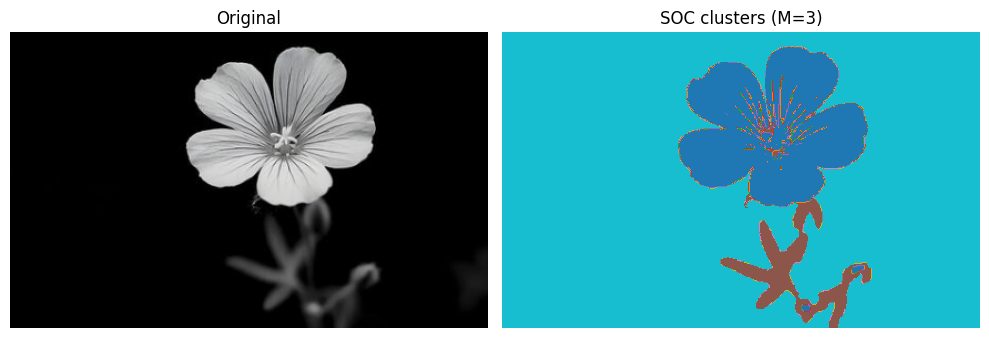

In [108]:
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = "flower.png"  
M_RANGE = range(2, 6)       

X, pixel_idx, shape = load_image_as_points(IMG_PATH)

best_M, best_gsi, best_labels = None, -np.inf, None
for M in M_RANGE:
    labels, centers, deltas = cluster_fixed_M(X, M)
    gsi, S_m, s_i = compute_gsi(X, labels)
    print(f"M={M}: GSI={gsi:.4f}")
    if gsi > best_gsi:
        best_M, best_gsi, best_labels = M, gsi, labels

print(f"\nBest M = {best_M} (GSI={best_gsi:.4f})")

full_labels = best_labels[pixel_idx].reshape(shape) 

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(plt.imread(IMG_PATH)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(full_labels, cmap="tab10"); axes[1].set_title(f"SOC clusters (M={best_M})"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("clustered_result.png", dpi=150)
print("Saved: clustered_result.png")

# Starting of the SOC algorithm

In [109]:
from scipy.interpolate import lagrange 
def find_eta(deltas, S_m, delta_bounds=(0.0, 0.16666)):
    deltas = np.asarray(deltas, dtype=float)
    if len(deltas) < 2:
        return float(deltas[0]) if len(deltas) else 0.0
    d = deltas.copy()
    idx = np.argsort(d)
    for i in range(1, len(idx)):
        a, b = idx[i - 1], idx[i]
        if d[b] - d[a] < 1e-9:
            d[b] += 1e-9 * (i + 1)
    poly = lagrange(d, S_m)
    roots = (poly - 1).roots
    real_roots = roots[np.abs(roots.imag) < 1e-8].real
    lo, hi = delta_bounds
    valid = real_roots[(real_roots >= lo) & (real_roots <= hi)]
    
    if len(valid) == 0:
        return float(d[np.argmax(S_m)])  
    if len(valid) == 1:
        return float(valid[0])
    eta = valid[np.argmin(np.abs(poly(valid) - 1))]
    return float(eta)

In [110]:
def update_betas(eta, deltas, beta_bounds=(0.1, 10.0)):
    deltas_safe = np.where(deltas == 0, 2, deltas)
    return np.clip(eta / deltas_safe, *beta_bounds)
    

In [111]:
def run_soc(X, M, n_iterations=10):
    betas = np.ones(M)
    best_labels, best_gsi = None, -np.inf
    history = []
    beta_hist = []
    for _ in range(n_iterations):
        labels, centers, deltas = cluster_fixed_M(X, M, betas)
        gsi_val, S_m, s_i = compute_gsi(X, labels)
        history.append(gsi_val)
        beta_hist.append(betas.copy())
        if gsi_val > best_gsi:
            best_labels, best_gsi = labels, gsi_val
        if len(S_m) != len(deltas) or np.isnan(S_m).any():
            betas = np.ones(M)
            continue
        eta = find_eta(deltas, S_m)
        new_betas = update_betas(eta, deltas)
        betas = np.ones(M)
        betas[:len(new_betas)] = new_betas
    return best_labels, best_gsi, history, beta_hist

GSI per M (plain IMC):
  M=2: GSI=0.6146
  M=3: GSI=0.6368
  M=4: GSI=0.6244
  M=5: GSI=0.6244
  M=6: GSI=0.6244
  M=7: GSI=0.6244
Optimum M = 3

Final SOC GSI history: [0.6368, 0.6336, 0.6365, 0.6309, 0.6354, 0.6247, 0.6289, 0.6156, 0.6085, 0.5394]
Best GSI = 0.6368

Beta values per iteration:
  Iter 1: GSI=0.6368 | β1=1.0000, β2=1.0000, β3=1.0000
  Iter 2: GSI=0.6336 | β1=0.8158, β2=0.8557, β3=0.9613
  Iter 3: GSI=0.6365 | β1=1.0462, β2=1.0382, β3=1.0000
  Iter 4: GSI=0.6309 | β1=0.7669, β2=0.8121, β3=0.9542
  Iter 5: GSI=0.6354 | β1=1.1189, β2=1.0972, β3=1.0000
  Iter 6: GSI=0.6247 | β1=0.7001, β2=0.7514, β3=0.9489
  Iter 7: GSI=0.6289 | β1=1.2365, β2=1.1931, β3=1.0000
  Iter 8: GSI=0.6156 | β1=0.6171, β2=0.6758, β3=0.9543
  Iter 9: GSI=0.6085 | β1=1.4374, β2=1.3527, β3=1.0000
  Iter 10: GSI=0.5394 | β1=0.4990, β2=0.5639, β3=0.9686


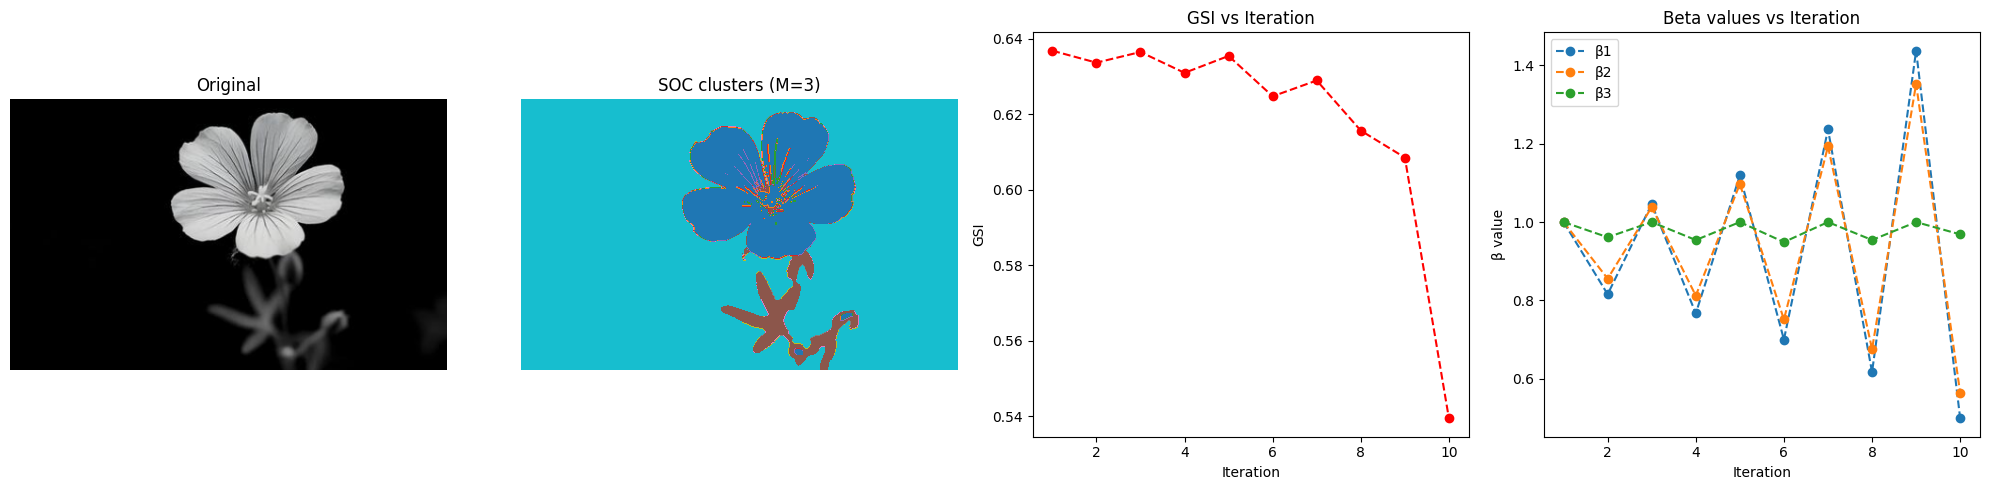

Saved: soc_result.png
Saved: beta_history.csv


In [113]:
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = "flower.png"   
M_RANGE = range(2, 8)
N_ITER = 10

X, pixel_idx, shape = load_image_as_points(IMG_PATH)


best_M, gsi_results = find_optimum_M(X, M_RANGE)
print("GSI per M (plain IMC):")
for M, gsi in gsi_results.items():
    print(f"  M={M}: GSI={gsi:.4f}")
print(f"Optimum M = {best_M}")


best_labels, best_gsi, history, beta_hist = run_soc(X, best_M, n_iterations=N_ITER)

print(f"\nFinal SOC GSI history: {[round(g,4) for g in history]}")
print(f"Best GSI = {best_gsi:.4f}")


print("\nBeta values per iteration:")
for it, betas in enumerate(beta_hist, start=1):
    beta_str = ", ".join(f"β{m+1}={b:.4f}" for m, b in enumerate(betas))
    print(f"  Iter {it}: GSI={history[it-1]:.4f} | {beta_str}")


beta_array = np.array(beta_hist)  

full_labels = best_labels[pixel_idx].reshape(shape)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(plt.imread(IMG_PATH)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(full_labels, cmap="tab10"); axes[1].set_title(f"SOC clusters (M={best_M})"); axes[1].axis("off")
axes[2].plot(range(1, len(history)+1), history, 'o--', color='red')
axes[2].set_title("GSI vs Iteration"); axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("GSI")
for m in range(best_M):
    axes[3].plot(range(1, len(beta_hist)+1), beta_array[:, m], 'o--', label=f"β{m+1}")
axes[3].set_title("Beta values vs Iteration")
axes[3].set_xlabel("Iteration"); axes[3].set_ylabel("β value")
axes[3].legend()
plt.tight_layout()
plt.savefig("soc_result.png", dpi=150)
plt.show()
print("Saved: soc_result.png")

import csv
with open("beta_history.csv", "w", newline="") as f:
    writer = csv.writer(f)
    header = ["iteration", "GSI"] + [f"beta_{m+1}" for m in range(best_M)]
    writer.writerow(header)
    for it, (gsi_val, betas) in enumerate(zip(history, beta_hist), start=1):
        writer.writerow([it, gsi_val] + list(betas))
print("Saved: beta_history.csv")

# Cluster validation indices

In [114]:
import numpy as np

def _cluster_indices(labels, M):
    return [labels == m for m in range(M)]

def cluster_centers(X, labels, M):
    D = X.shape[1]
    centers = np.zeros((M, D))
    for m in range(M):
        mask = labels == m
        if mask.sum() == 0:
            centers[m] = np.nan
        else:
            centers[m] = X[mask].mean(axis=0)
    return centers

def silhouette_per_point(X, labels, M):
    n = X.shape[0]
    s = np.zeros(n)

    diff = X[:, None, :] - X[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=-1))

    for i in range(n):
        own = labels[i]
        own_mask = (labels == own)
        own_mask[i] = False 

        if own_mask.sum() == 0:
            s[i] = 0.0  
            continue

        a_i = dist[i, own_mask].mean()

        b_i = np.inf
        for k in range(M):
            if k == own:
                continue
            k_mask = (labels == k)
            if k_mask.sum() == 0:
                continue
            b_k = dist[i, k_mask].mean()
            b_i = min(b_i, b_k)

        if not np.isfinite(b_i):
            s[i] = 0.0
        else:
            s[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0.0

    return s


def silhouette_per_cluster(X, labels, M):
    """S_m = mean silhouette width over points in cluster m. (Eq. 16)"""
    s = silhouette_per_point(X, labels, M)
    S = np.zeros(M)
    for m in range(M):
        mask = labels == m
        S[m] = s[mask].mean() if mask.sum() > 0 else 0.0
    return S


def gsi(X, labels, M=None):
    """GSI = (1/M) * sum_m S_m   (Eq. 17). Higher is better."""
    if M is None:
        M = int(labels.max()) + 1
    S = silhouette_per_cluster(X, labels, M)
    return S.mean(), S  


def pi(X, labels, M=None):
    
    if M is None:
        M = int(labels.max()) + 1
    centers = cluster_centers(X, labels, M)

    total = 0.0
    for m in range(M):
        mask = labels == m
        Nm = mask.sum()
        if Nm == 0:
            continue
        sq_dist_to_own = ((X[mask] - centers[m]) ** 2).sum(axis=1)
        numerator = sq_dist_to_own.sum() / Nm

        denom = 0.0
        for k in range(M):
            if not np.isnan(centers[k]).any():
                denom += ((centers[k] - centers[m]) ** 2).sum()

        total += numerator / denom if denom > 0 else 0.0

    return total

def si(X, labels, M=None):
  
    if M is None:
        M = int(labels.max()) + 1
    n = X.shape[0]
    centers = cluster_centers(X, labels, M)

    numerator = 0.0
    for m in range(M):
        mask = labels == m
        if mask.sum() == 0:
            continue
        numerator += ((X[mask] - centers[m]) ** 2).sum()

   
    min_sep = np.inf
    for m in range(M):
        if np.isnan(centers[m]).any():
            continue
        for k in range(M):
            if k == m or np.isnan(centers[k]).any():
                continue
            d2 = ((centers[k] - centers[m]) ** 2).sum()
            min_sep = min(min_sep, d2)

    if not np.isfinite(min_sep) or min_sep == 0:
        return np.nan

    return numerator / (n * min_sep)

def dunn_index(X, labels, M=None):
 
    if M is None:
        M = int(labels.max()) + 1
    centers = cluster_centers(X, labels, M)
    deltas = np.zeros(M)
    for m in range(M):
        mask = labels == m
        pts = X[mask]
        if len(pts) < 2:
            deltas[m] = 0.0
            continue
        diff = pts[:, None, :] - pts[None, :, :]
        dist = np.sqrt((diff ** 2).sum(axis=-1))
        deltas[m] = dist.max()

    max_delta = deltas.max()
    if max_delta == 0:
        return np.nan

   
    def centroid_linkage(m, k):
        Xm, Xk = X[labels == m], X[labels == k]
        vs, vt = centers[m], centers[k]
        term1 = np.sqrt(((Xm - vt) ** 2).sum(axis=1)).sum()
        term2 = np.sqrt(((Xk - vs) ** 2).sum(axis=1)).sum()
        return (term1 + term2) / (len(Xm) + len(Xk))

    min_overall = np.inf
    for m in range(M):
        if (labels == m).sum() == 0:
            continue
        min_k = np.inf
        for k in range(M):
            if k == m or (labels == k).sum() == 0:
                continue
            d_mk = centroid_linkage(m, k)
            min_k = min(min_k, d_mk / max_delta)
        if np.isfinite(min_k):
            min_overall = min(min_overall, min_k)

    return min_overall if np.isfinite(min_overall) else np.nan


def all_indices(X, labels, M=None):
    if M is None:
        M = int(labels.max()) + 1
    gsi_val, _ = gsi(X, labels, M)
    return {
        "GSI": gsi_val,
        "PI": pi(X, labels, M),
        "SI": si(X, labels, M),
        "DI": dunn_index(X, labels, M),
    }


In [115]:
import numpy as np
import pandas as pd

try:
    import pandas as pd
    _HAS_PANDAS = True
except ImportError:
    _HAS_PANDAS = False


def compare(X, labels_by_technique, M=None, sort_by="GSI"):
  
    X = np.asarray(X)
    rows = []

    for name, labels in labels_by_technique.items():
        labels = np.asarray(labels)
        m_used = M if M is not None else int(labels.max()) + 1
        scores = all_indices(X, labels, M=m_used)
        scores["Technique"] = name
        scores["M"] = m_used
        rows.append(scores)

    higher_better = {"GSI", "DI"}
    reverse = sort_by in higher_better
    rows.sort(key=lambda r: (r[sort_by] if not np.isnan(r[sort_by]) else
                              (-np.inf if reverse else np.inf)),
              reverse=reverse)

    _print_table(rows, sort_by)

    if _HAS_PANDAS:
        df = pd.DataFrame(rows)[["Technique", "M", "GSI", "PI", "SI", "DI"]]
        return df
    return rows


def _print_table(rows, sort_by):
    headers = ["Technique", "M", "GSI", "PI", "SI", "DI"]
    widths = [14, 4, 8, 8, 8, 8]

    def fmt_row(vals):
        out = []
        for v, w in zip(vals, widths):
            if isinstance(v, float):
                out.append(f"{v:>{w}.4f}" if not np.isnan(v) else f"{'NaN':>{w}}")
            else:
                out.append(f"{str(v):<{w}}" if v == vals[0] else f"{str(v):>{w}}")
        return " | ".join(out)

    print(fmt_row(headers))
    print("-" * (sum(widths) + 3 * (len(widths) - 1)))
    for r in rows:
        print(fmt_row([r["Technique"], r["M"], r["GSI"], r["PI"], r["SI"], r["DI"]]))

    direction = "higher better" if sort_by in ("GSI", "DI") else "lower better"
    print(f"\n(sorted by {sort_by}, {direction}; best technique listed first)")

In [ ]:
def run_kmeans(X, M, n_iterations=100, seed=0):
    
    rng = np.random.default_rng(seed)
    centers = X[rng.choice(len(X), M, replace=False)]

    for _ in range(n_iterations):
        d2 = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        labels = d2.argmin(axis=1)

        new_centers = np.array([
            X[labels == m].mean(axis=0) if (labels == m).any() else centers[m]
            for m in range(M)
        ])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    gsi, S_m, s_i = compute_gsi(X, labels)
    return labels, centers, gsi


def run_fcm(X, M, m_fuzz=2.0, n_iterations=100, seed=0):
    
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    U = rng.dirichlet(np.ones(M), size=n)       

    for _ in range(n_iterations):
        Um = U ** m_fuzz
        centers = (Um.T @ X) / Um.sum(axis=0)[:, None]

        d2 = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        d2 = np.where(d2 == 0, 1e-12, d2)
        inv = d2 ** (-1 / (m_fuzz - 1))
        U_new = inv / inv.sum(axis=1, keepdims=True)

        if np.allclose(U_new, U, atol=1e-6):
            U = U_new
            break
        U = U_new

    labels = U.argmax(axis=1)                    
    gsi, S_m, s_i = compute_gsi(X, labels)
    return labels, centers, gsi


def image_to_gsi(IMG_PATH, M, technique="kmeans"):
    
    X, pixel_idx, shape = load_image_as_points(IMG_PATH)

    if technique == "kmeans":
        labels, centers, gsi = run_kmeans(X, M)
    elif technique == "fcm":
        labels, centers, gsi = run_fcm(X, M)
    else:
        raise ValueError("technique must be 'kmeans' or 'fcm'")

    print(f"{technique.upper()} (M={M}): GSI={gsi:.4f}")
    return labels, gsi


# Running all at once

In [117]:
IMG_PATH = "flower.png"
M_KMEANS_FCM = 3             
M_RANGE = range(2, 8)         

X, pixel_idx, shape = load_image_as_points(IMG_PATH)

best_M_imc, gsi_results_imc = find_optimum_M(X, M_RANGE)
imc_labels, _, _ = cluster_fixed_M(X, best_M_imc)
print(f"IMC optimum M = {best_M_imc}")

best_M_soc, gsi_results_soc = find_optimum_M(X, M_RANGE)
soc_labels, soc_gsi, history, beta_hist = run_soc(X, best_M_soc)
print(f"SOC optimum M = {best_M_soc}")

km_labels, _, _  = run_kmeans(X, M_KMEANS_FCM)
fcm_labels, _, _ = run_fcm(X, M_KMEANS_FCM)

df = compare(
    X,
    {
        f"IMC (M={best_M_imc})": imc_labels,
        f"SOC (M={best_M_soc})": soc_labels,
        f"K-means (M={M_KMEANS_FCM})": km_labels,
        f"FCM (M={M_KMEANS_FCM})": fcm_labels,
    },
    M=None,          
    sort_by="GSI"
)

IMC optimum M = 3
SOC optimum M = 3
Technique      |    M |      GSI |       PI |       SI |       DI
-----------------------------------------------------------------
IMC (M=3)      |    3 |   0.6368 |   0.0661 |   0.1512 |   0.5300
SOC (M=3)      |    3 |   0.6368 |   0.0661 |   0.1512 |   0.5300
FCM (M=3)      |    3 |   0.5745 |   0.0753 |   0.1165 |   0.7442
K-means (M=3)  |    3 |   0.5724 |   0.0754 |   0.1161 |   0.7241

(sorted by GSI, higher better; best technique listed first)
